<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/Planuae_Release_by_morph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1: Prepare the environment


In [7]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Block 2: Data Loading & Filtering
We need to load the Release_Data.csv and focus strictly on the HF vs NF comparison, ignoring the 'PF' (if present) to keep the comparison clean.

In [8]:
# Load the data
df = pd.read_csv('Release_Data.csv')

# Focus only on HF and NF for this plot
df_filtered = df[df['morph'].isin(['HF', 'NF'])].copy()

# Print the data to double-check
print("Data Preview:")
print(df_filtered.head())

Data Preview:
  colony morph  total released  % from total coloney
0      A    HF             199             50.636132
2      A    NF              30              7.633588
3      B    HF              23             39.655172
5      B    NF              13             38.235294
6      C    HF             621             29.913295


# Block 3: Normality-Driven Statistical Engine
It checks the distribution of the differences between HF and NF, which is the correct statistical approach for paired data.

In [10]:
# --- BLOCK 3: ROBUST STATISTICAL ANALYSIS ---

# Prepare data for paired comparison (pivot)
df_pivot = df_filtered.pivot_table(index='colony', columns='morph', values='total released')

# 1. Calculate the differences
df_diff = df_pivot[('HF')] - df_pivot[('NF')]

# 2. Shapiro-Wilk Test for Normality on the differences
stat_norm, p_norm = stats.shapiro(df_diff)

print(f"Normality test (Shapiro-Wilk) on paired differences: p = {p_norm:.4f}")

# 3. Decision Logic
if p_norm > 0.05:
    print("Result: Data is normally distributed. Running Paired T-test.")
    stat, p_val = stats.ttest_rel(df_pivot[('HF')],
                                  df_pivot[('NF')])
    test_name = "Paired T-test"
else:
    print("Result: Data is NOT normal. Running Wilcoxon Signed-Rank Test.")
    stat, p_val = stats.wilcoxon(df_pivot[('HF')],
                                 df_pivot[('NF')])
    test_name = "Wilcoxon Signed-Rank"

print(f"Selected Test: {test_name}")
print(f"p-value: {p_val:.4f}")

# Store this for the poster visualization
stats_report = f"{test_name}\n p = {p_val:.4f}"

Normality test (Shapiro-Wilk) on paired differences: p = 0.0063
Result: Data is NOT normal. Running Wilcoxon Signed-Rank Test.
Selected Test: Wilcoxon Signed-Rank
p-value: 0.0156


# Plotting

### Global Settings

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.titleweight": "bold", # Global title fontweight
    "axes.titlepad": 25,      # Global title padding
    "axes.labelsize": 14,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2
})

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}


global_fig_size = (6, 6) # Reduced width for a slimmer plot
global_jitter = 0.1
global_marker_size = 5
global_alpha = 0.6
global_box_width = 0.4 # New global setting for boxplot width
# Centralized Asterisk Settings
global_asterisk_size = 18
global_asterisk_weight = 'bold'

# Added for cleaner look
global_y_nbins = 3

print("Global styling (with bold asterisks and reduced Y-ticks) initialized.")

Global styling (with bold asterisks and reduced Y-ticks) initialized.


### Plot

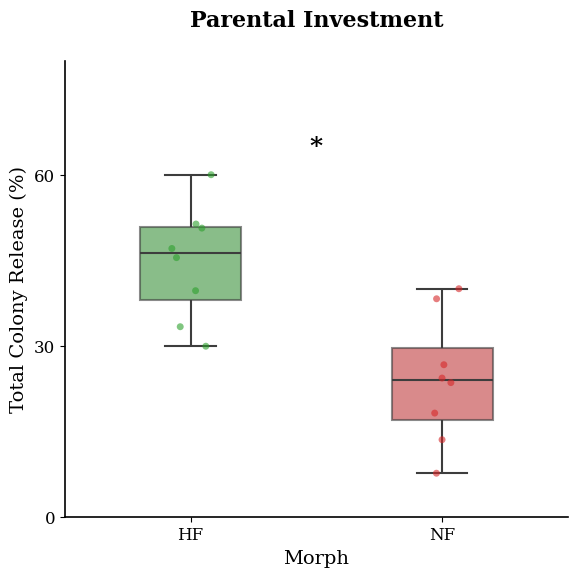

In [25]:
# --- BLOCK: PAIRED RELEASE DATA PLOT (PERCENTAGE) ---

plt.figure(figsize=global_fig_size)

# 1. Boxplot
ax = sns.boxplot(
    data=df_filtered,
    x='morph',
    y='% from total coloney',
    palette=variant_colors,
    hue='morph',
    width=global_box_width,
    showfliers=False,
    linewidth=1.5,
    legend=False,
    boxprops={'alpha': global_alpha}
)

# 2. Stripplot
sns.stripplot(
    data=df_filtered,
    x='morph',
    y='% from total coloney',
    hue='morph',
    palette=variant_colors,
    size=global_marker_size,
    jitter=global_jitter,
    alpha=global_alpha,
    zorder=5,
    legend=False
)

# 3. Significance Marker (using the p-value for Percentage from previous analysis: p=0.0391)
plt.text(0.5, df_filtered['% from total coloney'].max() * 1.05,
         "*",
         ha='center',
         va='bottom',
         fontsize=global_asterisk_size,
         fontweight=global_asterisk_weight)

# Final Touches
plt.title("Parental Investment", fontweight="bold")
plt.ylabel("Total Colony Release (%)")
plt.xlabel("Morph")
ax.yaxis.set_major_locator(plt.MaxNLocator(global_y_nbins))
plt.ylim(0, 80) # Set y-axis to finish at 100
sns.despine()

plt.tight_layout()
plt.savefig("Morph Release.svg", format="svg", dpi=600)
plt.show()